### Remap WOA18 to tx2_3

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf
import numpy as np
import datetime
import matplotlib.pyplot as plt

In [3]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [4]:
def weighted_temporal_mean(da):
    """
    weight by days in each month
    """
    # Determine the month length
    month_length = da.time.dt.days_in_month

    # Calculate the weights
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()

    # Make sure the weights in each year add up to 1
    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0)

    # Subset our dataset for our variable
    obs = da

    # Setup our masking for nan values
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)

    # Calculate the numerator
    obs_sum = (obs * wgts).resample(time="YS").sum(dim="time")

    # Calculate the denominator
    ones_out = (ones * wgts).resample(time="YS").sum(dim="time")

    # Return the weighted average
    return obs_sum / ones_out

In [5]:
fname = '../mesh/tx2_3v3_grid.nc'
ds_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b', 'nx' : 'xh', 'ny' : 'yh',
                                        'depth' : 'z_l', 'tmask' : 'mask'})
ds_out

<xarray.Dataset> Size: 42MB
Dimensions:  (yh: 480, xh: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: yh, xh, nxp, nyp
Data variables: (12/20)
    lon      (yh, xh) float64 2MB ...
    lat      (yh, xh) float64 2MB ...
    ulon     (yh, nxp) float64 2MB ...
    ulat     (yh, nxp) float64 2MB ...
    vlon     (nyp, xh) float64 2MB ...
    vlat     (nyp, xh) float64 2MB ...
    ...       ...
    tarea    (yh, xh) float64 2MB ...
    mask     (yh, xh) float64 2MB ...
    angle    (yh, xh) float64 2MB ...
    z_l      (yh, xh) float64 2MB ...
    ar       (yh, xh) float64 2MB ...
    egs      (yh, xh) float64 2MB ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

In [6]:
infile = '/glade/campaign/cgd/oce/datasets/obs/woa18/woa18_decav_merged_monthly_deep_04.nc'
ds_in = xr.open_dataset(infile)
ds_in

<xarray.Dataset> Size: 15GB
Dimensions:  (time: 12, depth: 102, lat: 720, lon: 1440)
Coordinates:
  * time     (time) float64 96B 372.5 373.5 374.5 375.5 ... 381.5 382.5 383.5
  * depth    (depth) float64 816B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    t_an     (time, depth, lat, lon) float32 5GB ...
    s_an     (time, depth, lat, lon) float32 5GB ...
    theta0   (time, depth, lat, lon) float32 5GB ...

In [7]:
ds_in["mask"] = xr.where(~np.isnan(ds_in["theta0"].isel(time=0,depth=0)), 1, 0)

In [8]:
def regrid_tracer(fld, ds_in, ds_out, method='bilinear'): # method = 'conservative_normed'

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    #fld_out = regrid(ds_in[fld],  skipna=True, na_thres=.25)#[0,0,:]#.where(ds_in.lat>ds_out.geolat.min())
    fld_out = regrid(ds_in[fld])
    return fld_out

#### Potential temperature

In [9]:
temp = regrid_tracer('theta0', ds_in, ds_out)
temp

<xarray.DataArray (time: 12, depth: 102, yh: 480, xh: 540)> Size: 1GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]],
      shape=(12, 102, 480, 540), dtype=float32)
Coordinates:
  * time     (time) float64 96B 372.5 373.5 374.5 375.5 ... 381.5 382.5 383.5
  * depth    (depth) float64 816B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  bilinear

##### Visual inspection
Make sure original and remapped plots look similar.

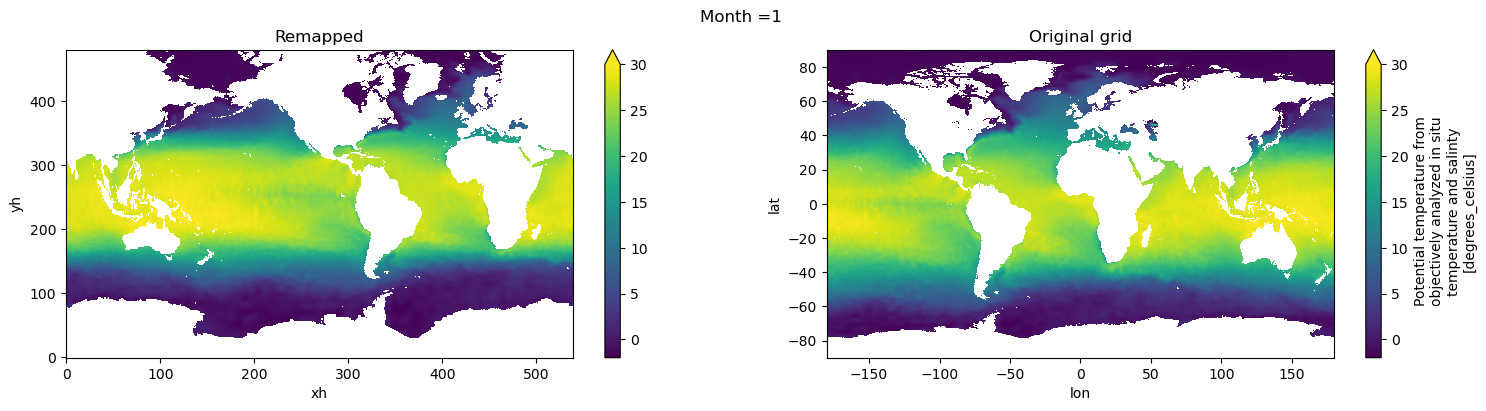

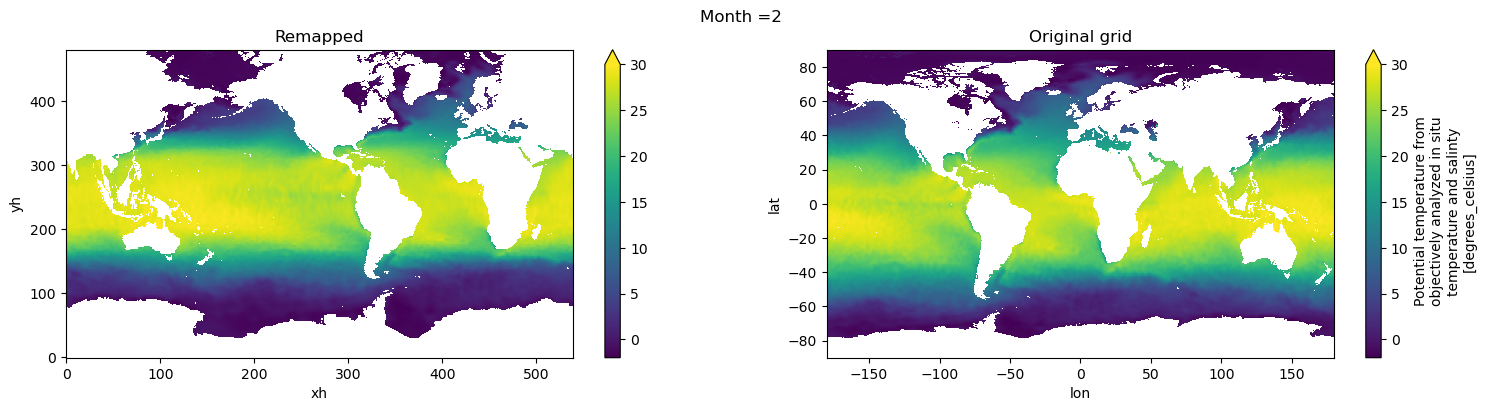

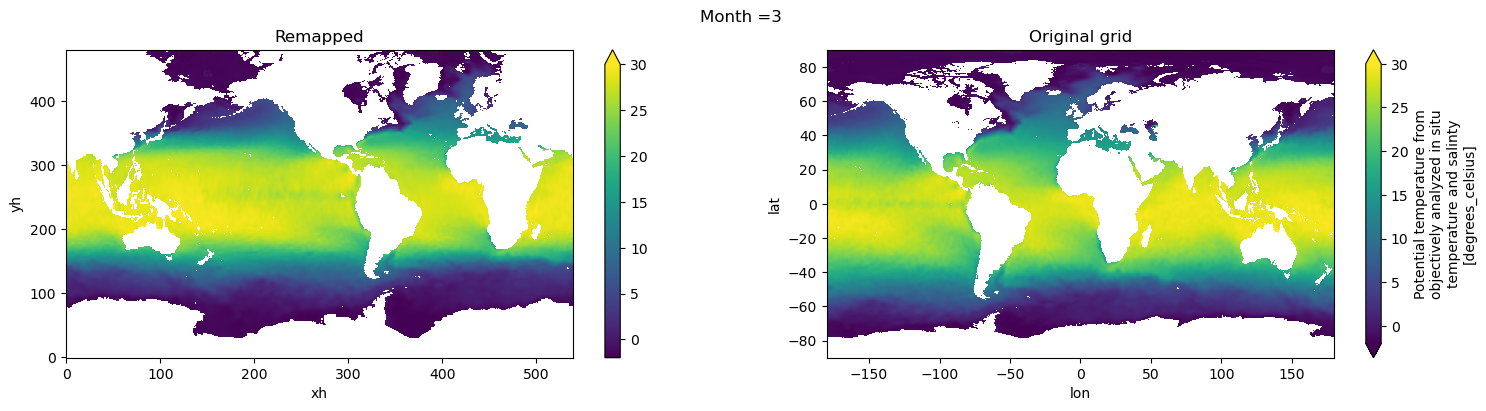

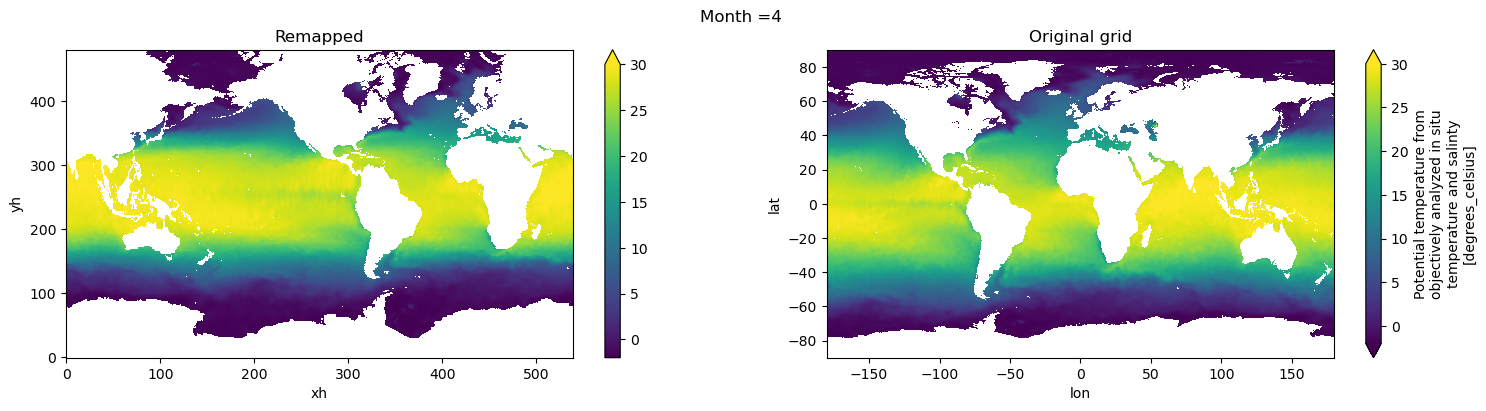

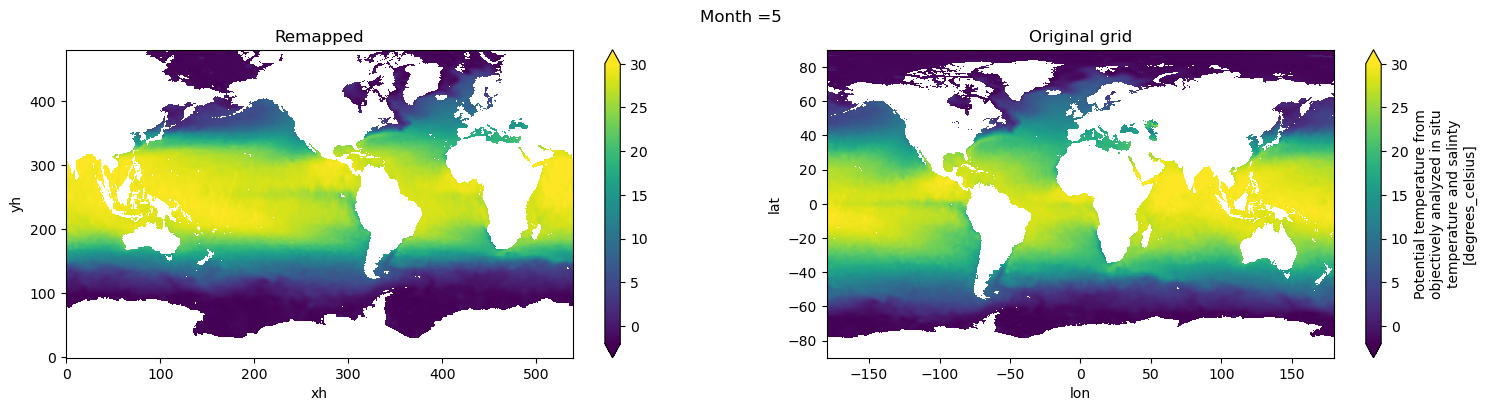

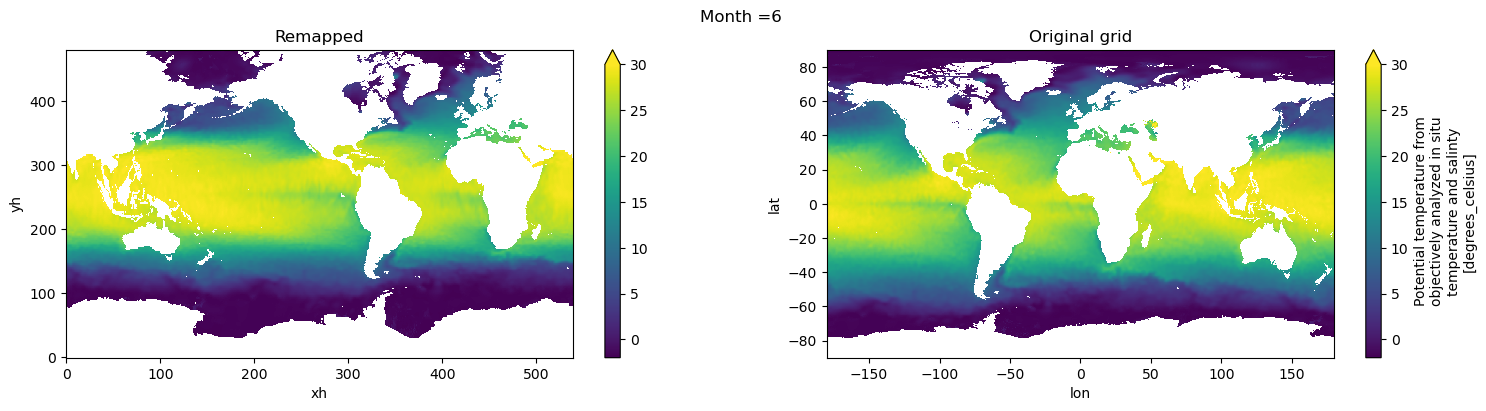

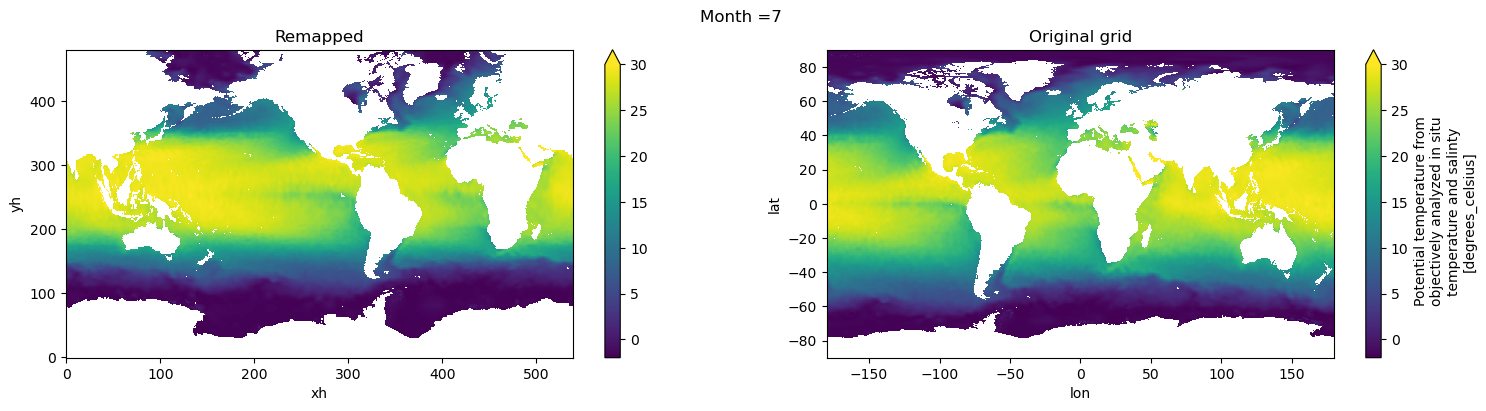

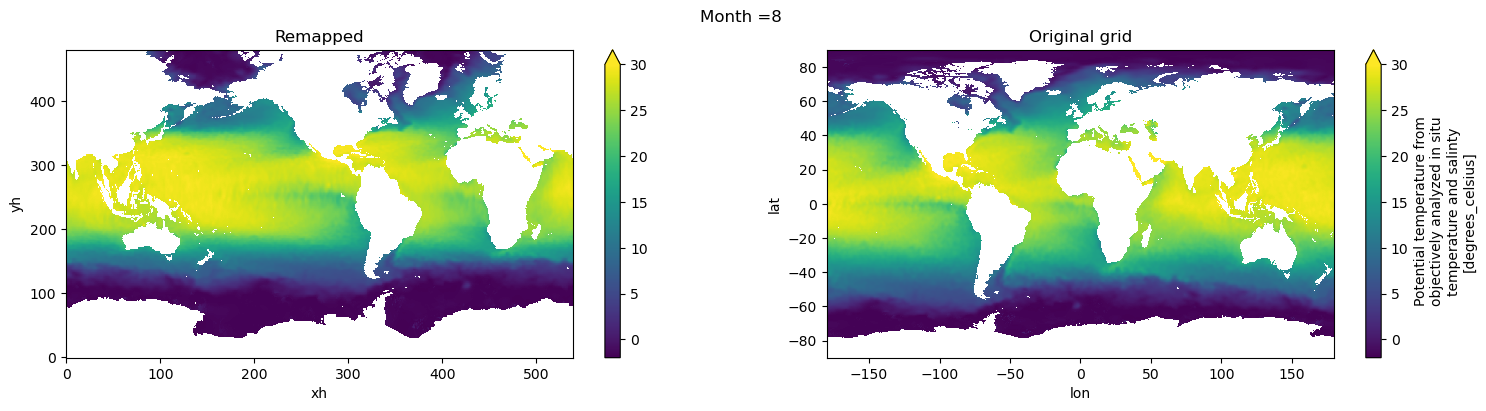

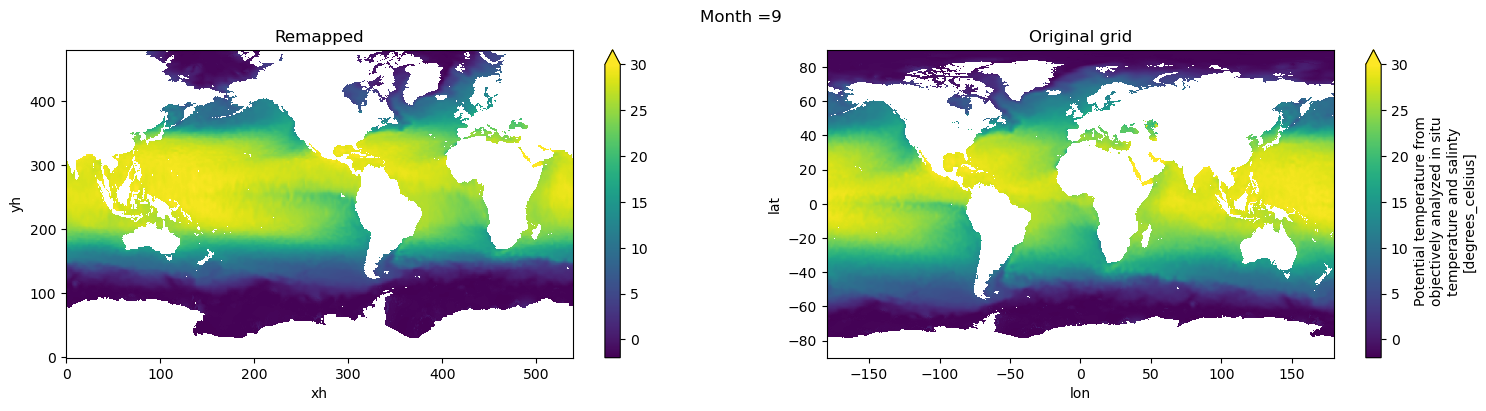

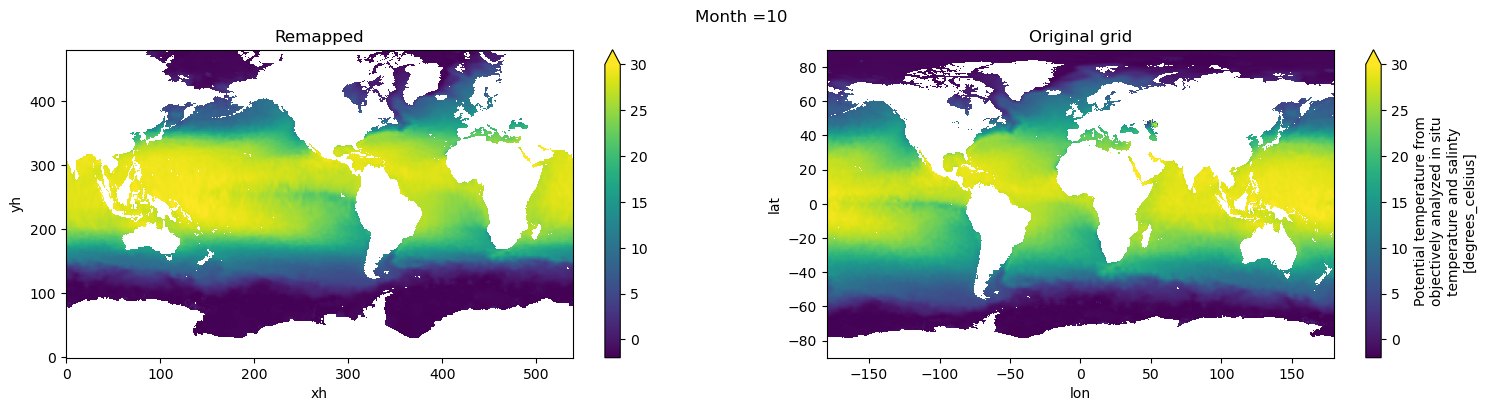

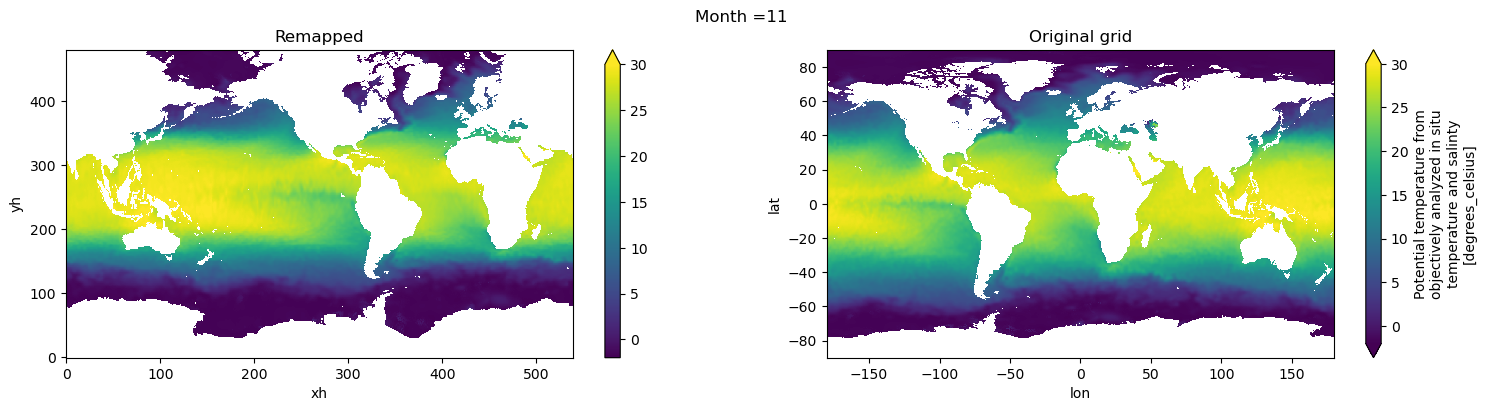

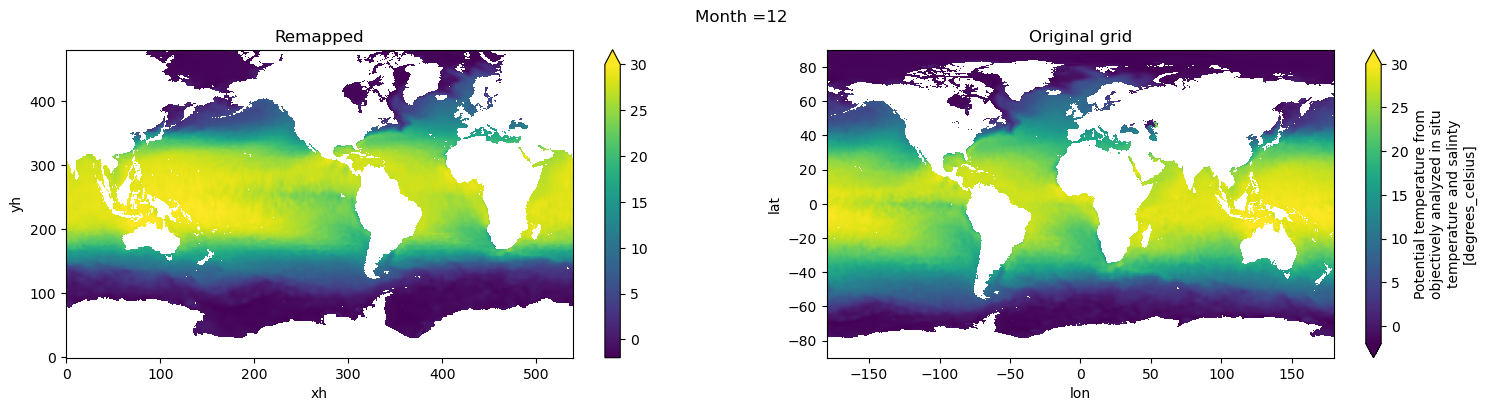

In [10]:
#%matplotlib ipympl

# visual inspection. Make sure original and remapped plots look similar
for t in range(len(temp.time)):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
  temp[t,0,:,:].plot.pcolormesh(ax=axes[0], vmin=-2,vmax=30)
  ds_in['theta0'][t,0,:,:].plot.pcolormesh(ax=axes[1], vmin=-2,vmax=30)
  axes[0].set_title('Remapped')
  axes[1].set_title('Original grid')
  plt.suptitle('Month ='+ str(t+1))

#### Salinity

In [11]:
salt = regrid_tracer('s_an', ds_in, ds_out)

##### Visual inspection
Make sure original and remapped plots look similar.

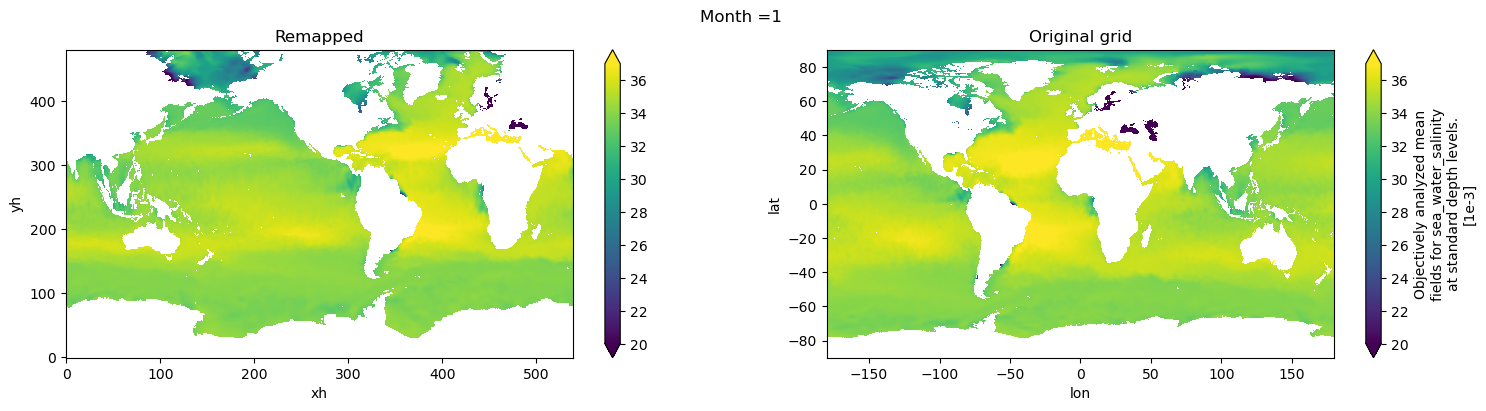

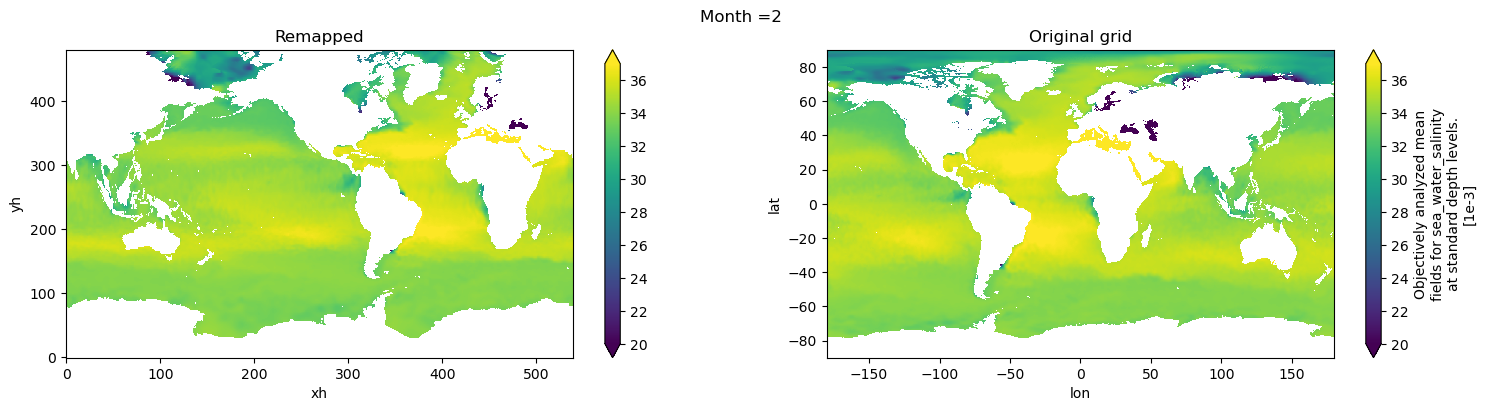

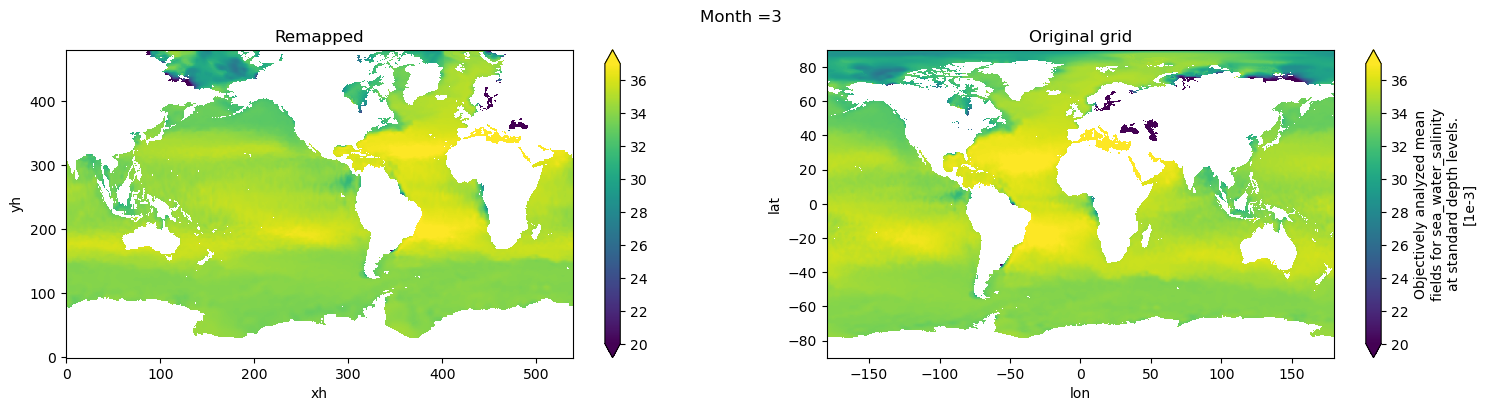

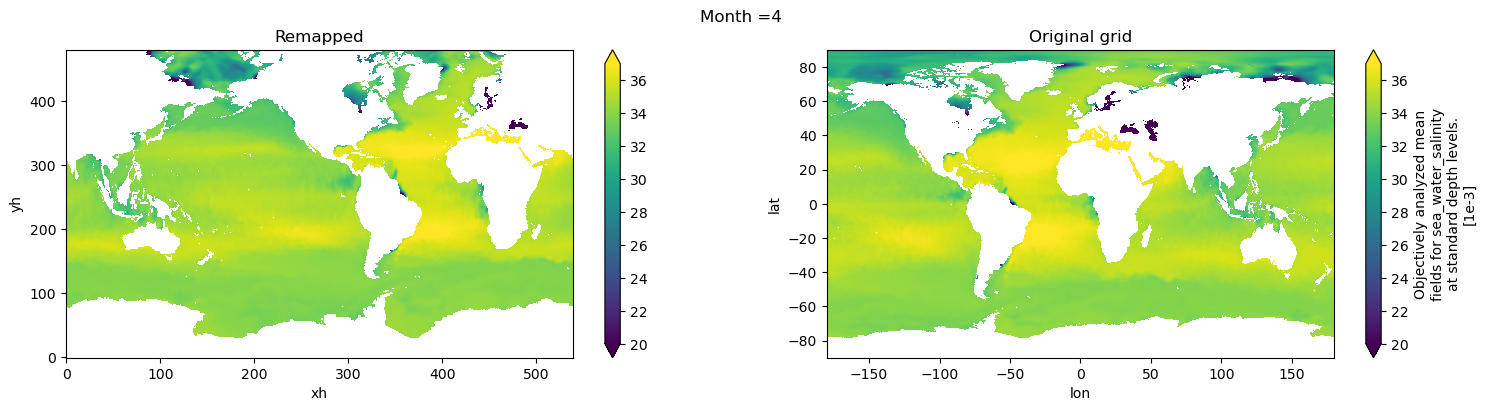

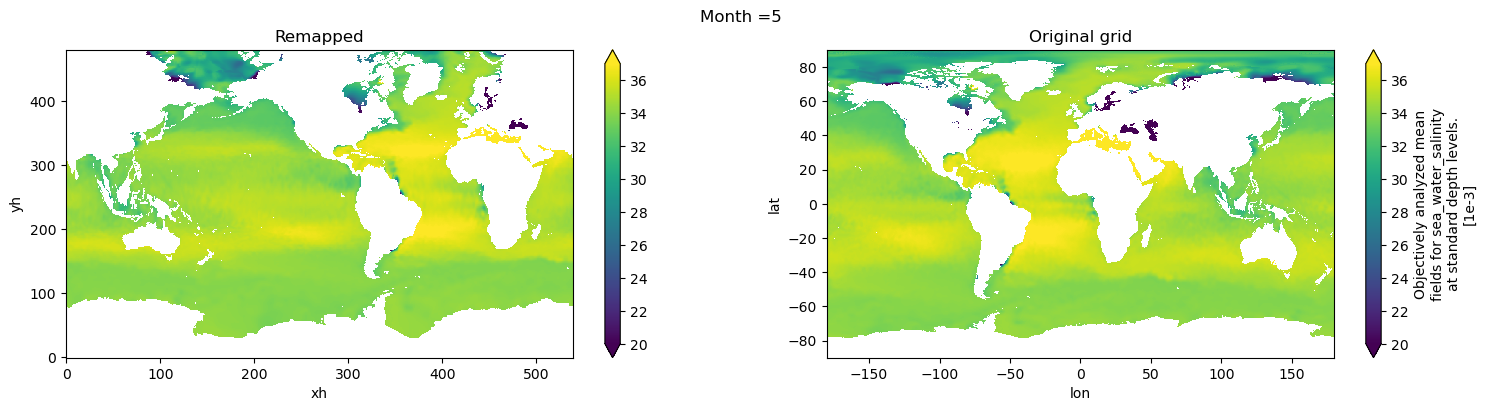

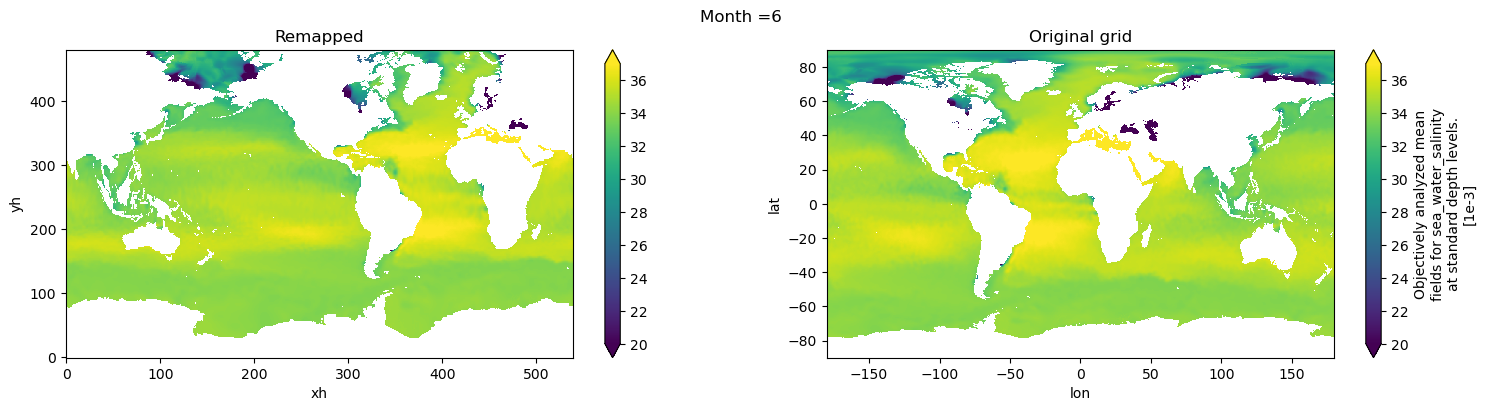

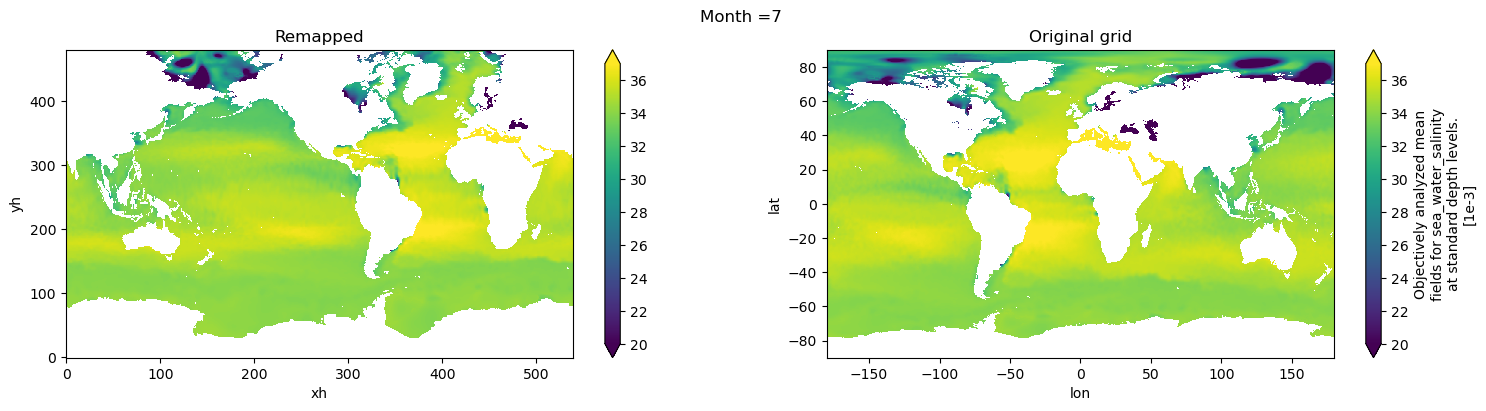

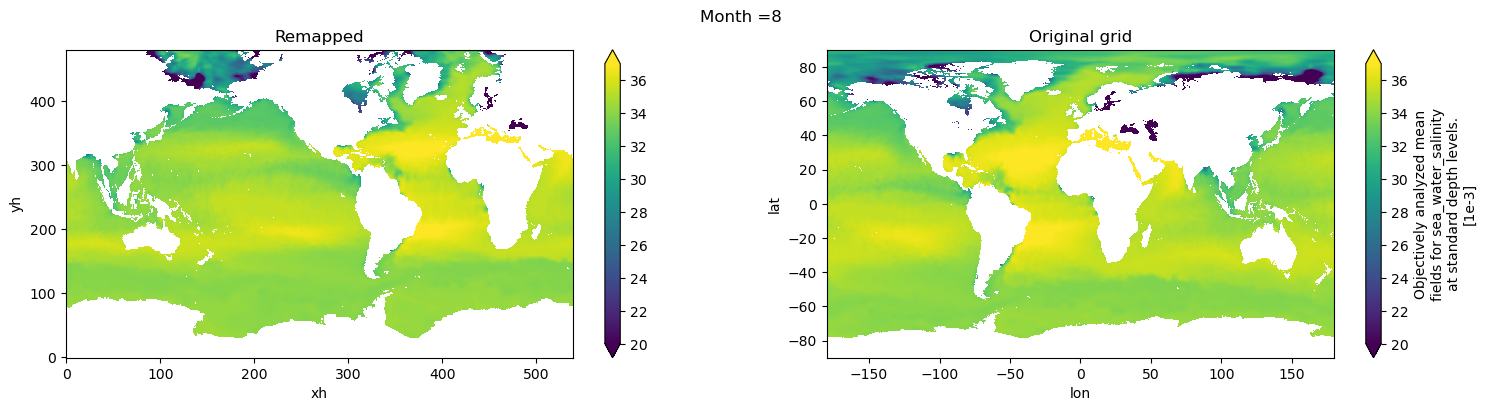

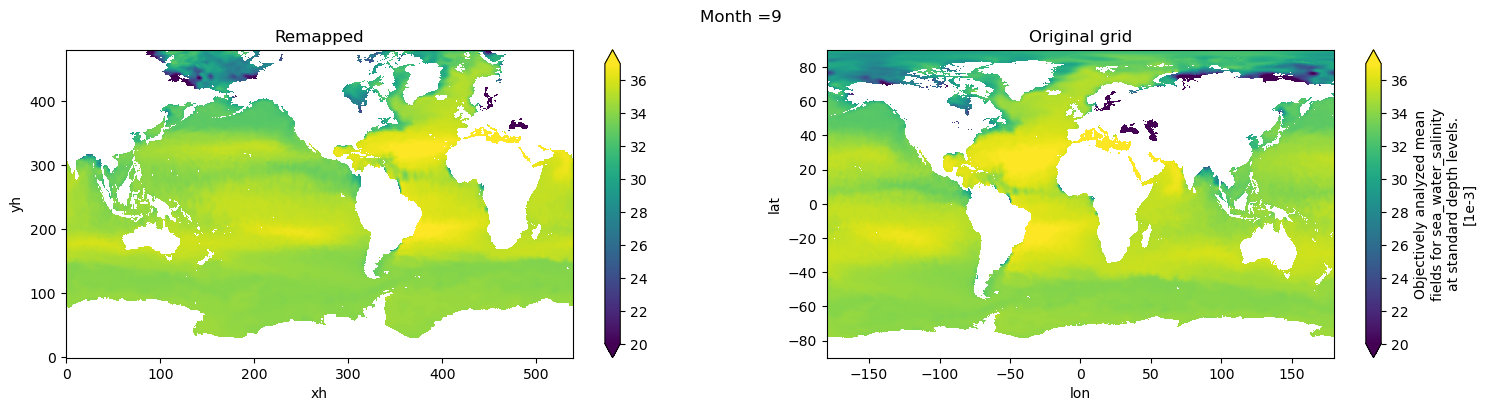

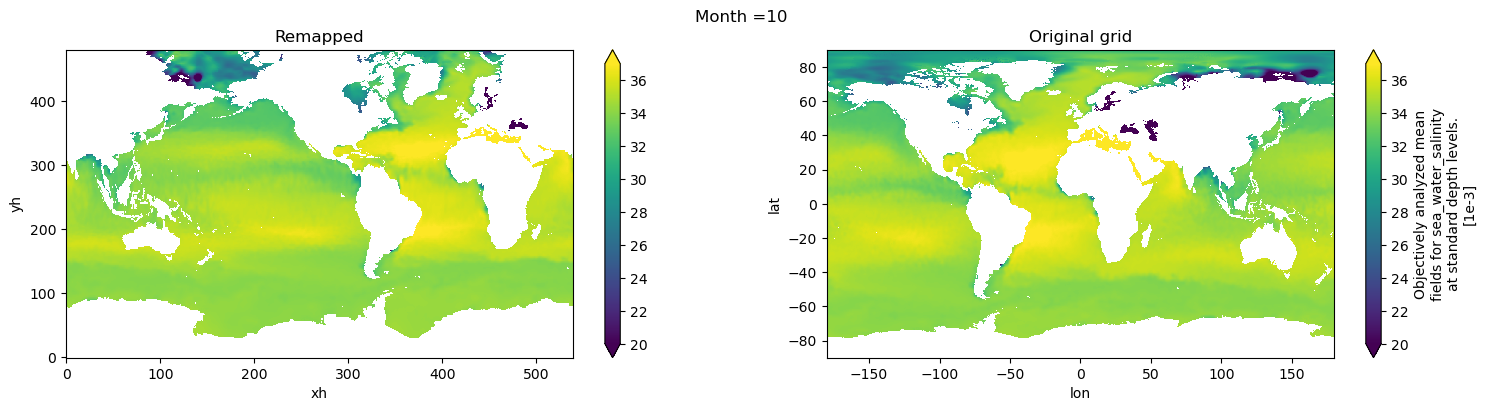

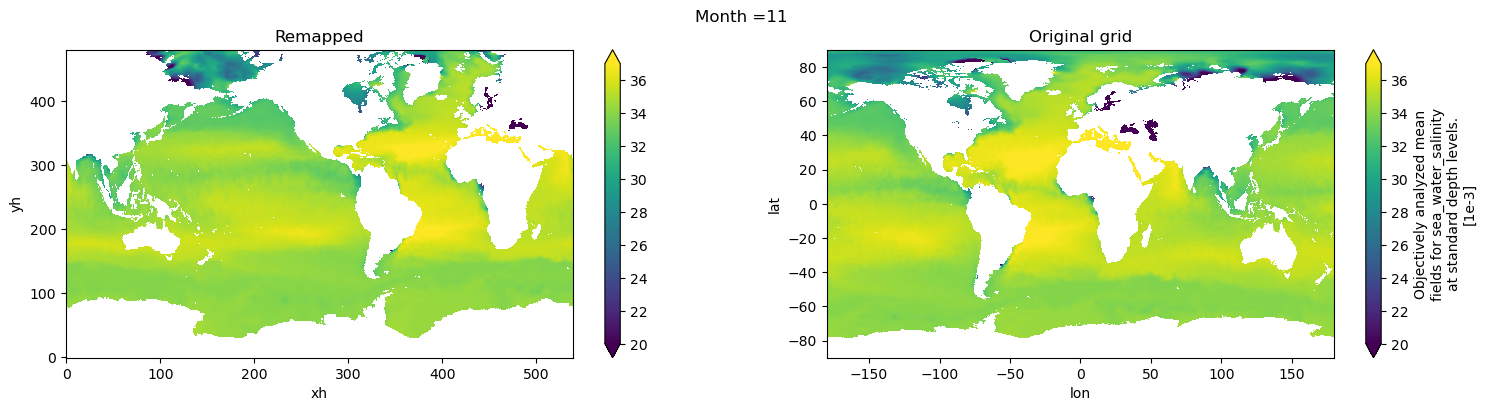

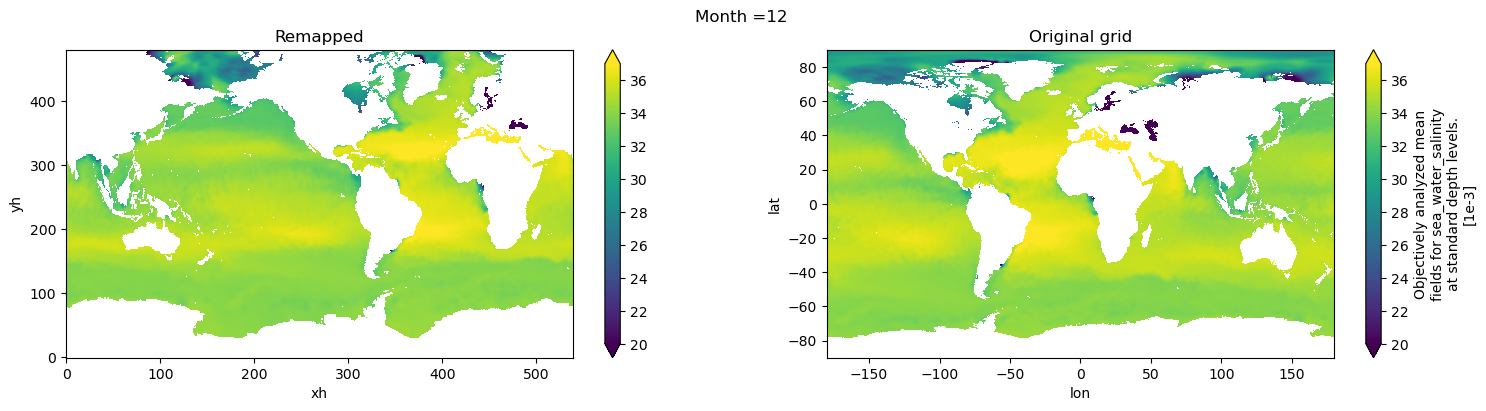

In [12]:
# visual inspection. Make sure original and remapped plots look similar
for t in range(len(temp.time)):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
  salt[t,0,:,:].plot.pcolormesh(ax=axes[0], vmin=20,vmax=37)
  ds_in['s_an'][t,0,:,:].plot.pcolormesh(ax=axes[1], vmin=20,vmax=37)
  axes[0].set_title('Remapped')
  axes[1].set_title('Original grid')
  plt.suptitle('Month ='+ str(t+1))

#### WOA09 layer depths
To keep consistency with previous datasets and to avoid modifying parameter DIAG_COORD_DEF_Z in CESM/MOM6, we will vertically interpolate temp and salt to the 34 layer depths from WOA09

In [13]:
depths_woa09 = np.array([2.5, 10, 20, 32.5, 51.25, 75, 100, 125, 156.25, 200, 250, 312.5, 400,
500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1537.5, 1750,
2062.5, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]);

#### Monthly means

In [14]:
temp_depths_woa09 = temp.interp(depth=depths_woa09).rename('thetao').rename({'depth':'z_l'})

In [15]:
# Global attrs
temp_depths_woa09.attrs['title'] = 'Potential temperature (monthly mean) from WOA18 remapped to tx2_3 and vertically interpolated to the WOA09 depths.'
temp_depths_woa09.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
temp_depths_woa09.attrs['date'] = today
temp_depths_woa09.attrs['infile'] = infile
temp_depths_woa09.attrs['url'] = 'https://github.com/NCAR/tx2_3/woa18'
# save
fname = 'WOA18_TEMP_tx2_3v3_35lev_monthly_avg_{}.nc'.format(today)
temp_depths_woa09.to_netcdf(fname)

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/dask/config.py:786: FutureWarning: Dask configuration key 'allowed-failures' has been deprecated; please use 'distributed.scheduler.allowed-failures' instead
  warnings.warn(


In [16]:
salt_depths_woa09 = salt.interp(depth=depths_woa09).rename('so').rename({'depth':'z_l'})

In [17]:
# Global attrs
salt_depths_woa09.attrs['title'] = 'Salinity (monthly mean) from WOA18 remapped to tx2_3 and vertically interpolated to the WOA09 depths.'
salt_depths_woa09.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
salt_depths_woa09.attrs['date'] = today
salt_depths_woa09.attrs['infile'] = infile
temp_depths_woa09.attrs['url'] = 'https://github.com/NCAR/tx2_3/woa18'
# save
fname = 'WOA18_SALT_tx2_3v3_35lev_monthly_avg_{}.nc'.format(today)
salt_depths_woa09.to_netcdf(fname)

#### Annual mean

In [18]:
temp['time'] = xr.date_range("0001-01-01", periods=12, freq="MS", calendar="noleap", use_cftime=True)

In [19]:
temp_depths_woa09_ann = weighted_temporal_mean(temp).interp(depth=depths_woa09).rename('thetao').rename({'depth':'z_l'})

In [20]:
# Global attrs
temp_depths_woa09_ann.attrs['title'] = 'Potential temperature from WOA18 (annual mean) remapped to tx2_3 and vertically interpolated to the WOA09 depths.'
temp_depths_woa09_ann.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
temp_depths_woa09_ann.attrs['date'] = today
temp_depths_woa09_ann.attrs['infile'] = infile
temp_depths_woa09.attrs['url'] = 'https://github.com/NCAR/tx2_3/woa18'
# save
fname = 'WOA18_TEMP_tx2_3v3_35lev_ann_avg_{}.nc'.format(today)
temp_depths_woa09_ann.to_netcdf(fname)

In [21]:
salt['time'] = xr.date_range("0001-01-01", periods=12, freq="MS", calendar="noleap", use_cftime=True)

In [22]:
salt_depths_woa09_ann = weighted_temporal_mean(salt).interp(depth=depths_woa09).rename('so').rename({'depth':'z_l'})

In [23]:
# Global attrs
salt_depths_woa09_ann.attrs['title'] = 'Salinity from WOA18 (annual mean) remapped to tx2_3 and vertically interpolated to the WOA09 depths.'
salt_depths_woa09_ann.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
salt_depths_woa09_ann.attrs['date'] = today
salt_depths_woa09_ann.attrs['infile'] = infile
temp_depths_woa09.attrs['url'] = 'https://github.com/NCAR/tx2_3/woa18'
# save
fname = 'WOA18_SALT_tx2_3v3_35lev_ann_avg_{}.nc'.format(today)
salt_depths_woa09_ann.to_netcdf(fname)